# Bac à sable pour outils

## importations de base

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import List, Union
import numpy as np

from scipy.optimize import curve_fit


# Baseline

## Valeurs pour tests (points expérimentaux et modélisation selon ComBase)

In [ ]:
#Poutlry Salmonella Baranyi_complet ComBaseID SOscar36_5

dummy_params_baranyi = {'Initial Value': 4.309, 'Lag': 1.0775, 'Maximum Rate': 0.685, 'Final Value': 9.835}

dummy_val_baranyi = {
    'time': [0, 0.32799999999999996, 0.6559999999999999, 0.9839999999999999, 1.3119999999999998, 1.6399999999999997, 1.9679999999999997, 2.296, 2.6239999999999997,
                        2.9519999999999995, 3.2799999999999994, 3.6079999999999997, 3.9359999999999995, 4.263999999999999, 4.592, 4.919999999999999, 5.247999999999999, 5.576,
                        5.903999999999999, 6.231999999999999, 6.559999999999999, 6.887999999999999, 7.215999999999999, 7.543999999999999, 7.871999999999999, 8.2, 8.527999999999999,
                        8.855999999999998, 9.184, 9.511999999999999, 9.839999999999998, 10.168, 10.495999999999999, 10.823999999999998, 11.152, 11.479999999999999, 11.807999999999998,
                        12.136, 12.463999999999999, 12.791999999999998, 13.119999999999997, 13.447999999999999, 13.775999999999998, 14.103999999999997, 14.431999999999999,
                        14.759999999999998, 15.087999999999997, 15.415999999999999, 15.743999999999998, 16.4],
    'logC': [4.308712286482676, 4.384066439911397, 4.478959357392312, 4.59453269179504, 4.730569480263076, 4.885548688727838, 5.057007945895253, 5.242045810498657,
                        5.43777495995431, 5.641619555634065, 5.8514469865044605, 6.065578747650244, 6.282734717730072, 6.501951599444913, 6.722498600081494, 6.9437998267655185,
                        7.165364563413286, 7.386722174017358, 7.607356223188182, 7.826631540338278, 8.043708264469785, 8.257439323833239, 8.46625457112362, 8.6680493872788,
                        8.860120835408484, 9.039226375548807, 9.201856628172537, 9.344769968753495, 9.465698657067566, 9.563959529905274, 9.640655668092602, 9.698352275279305,
                        9.740410865221353, 9.770305415365101, 9.791148740957704, 9.805477581991411, 9.815229480694583, 9.821820046831068, 9.82625270430541, 9.829224251232908,
                        9.831211900611839, 9.832539450073028, 9.833425235512934, 9.834015867167928, 9.834409518272565, 9.834671805522992, 9.834846531244626, 9.834962911460941,
                        9.835040422448362, 9.835126419571193]
    }

dummy_param_linear = {'Initial Value': 4.816, 'Maximum Rate': 0.392}

dummy_val_linear = {
    'time': [ 0, 0.32799999999999996, 0.6559999999999999, 0.9839999999999999, 1.3119999999999998, 1.6399999999999997, 1.9679999999999997, 2.296, 2.6239999999999997, 2.9519999999999995,
             3.2799999999999994, 3.6079999999999997, 3.9359999999999995, 4.263999999999999, 4.592, 4.919999999999999, 5.247999999999999, 5.576, 5.903999999999999, 6.231999999999999,
             6.559999999999999, 6.887999999999999, 7.215999999999999, 7.543999999999999, 7.871999999999999, 8.2, 8.527999999999999, 8.855999999999998, 9.184, 9.511999999999999,
             9.839999999999998, 10.168, 10.495999999999999, 10.823999999999998, 11.152, 11.479999999999999, 11.807999999999998, 12.136, 12.463999999999999, 12.791999999999998,
             13.119999999999997, 13.447999999999999, 13.775999999999998, 14.103999999999997, 14.431999999999999, 14.759999999999998, 15.087999999999997, 15.415999999999999,
             15.743999999999998, 16.4],
    'logC': [4.8158857650406945, 4.944543433574419, 5.073201102108144, 5.201858770641869, 5.330516439175594, 5.459174107709319, 5.587831776243044, 5.716489444776768, 5.845147113310492,
             5.973804781844217, 6.102462450377942, 6.231120118911667, 6.359777787445392, 6.488435455979117, 6.6170931245128415, 6.745750793046566, 6.874408461580291, 7.003066130114016,
             7.131723798647741, 7.260381467181466, 7.3890391357151906, 7.517696804248915, 7.64635447278264, 7.775012141316364, 7.90366980985009, 8.032327478383815, 8.16098514691754,
             8.289642815451263, 8.41830048398499, 8.546958152518712, 8.675615821052437, 8.804273489586162, 8.932931158119889, 9.061588826653612, 9.190246495187338, 9.318904163721061,
             9.447561832254786, 9.576219500788511, 9.704877169322236, 9.83353483785596, 9.962192506389686, 10.09085017492341, 10.219507843457135, 10.34816551199086, 10.476823180524585,
             10.60548084905831, 10.734138517592033, 10.86279618612576, 10.991453854659484, 11.248769191726934]
    }

dummy_train = {
    'time': [1.2,2.1,2.9,3.5,4.1,4.9,5.9,7,8.6,11.1,16.4],
    'logC': [4.76,5.08,5.46,6.06,6.28,7.11,7.59,8.47,9.11,9.41,10.2]
    }

## Classe ClassicalModel : modèles de croissance micro classiques

In [3]:
class ClassicalModel:
    def __init__(self) -> None:
        self.params: dict | None = None
        self.model: str | None = None

    def fit(
        self,
        time: List[float],
        logC: List[float],
        model: str = "linear",
    ) -> None:
        """
        fits a model logC = f(time)

        Parameters
        ----------
        time : list[float]
        logC : list[float]
        model : str, default "linear"
        """
        x = np.asarray(time, dtype=float)
        y = np.asarray(logC, dtype=float)

        if x.shape != y.shape:
            raise ValueError("time and logC should have the same length")

        self.model = model

        if model == "linear":
            self.model = model
            self._fit_linear(x, y)

        elif model == 'baranyi':
            self.model = model
            self._fit_baranyi(x, y)

        else:
            raise NotImplementedError(
                f"Model '{model}' not implemented"
            )


    def predict(self, time: Union[float, List[float]]) -> Union[float, List[float]]:
        if self.params is None or self.model is None:
            raise RuntimeError("Model has to be trained with fit() before predict().")

        if self.model == "linear":
            return self._predict_linear(time)

        elif self.model == 'baranyi':
            return self._predict_baranyi(time)

        else:
            raise NotImplementedError(
                f"Prediction not implemented for model '{self.model}'"
            )

    #Linear model
    def _fit_linear(self, x: np.ndarray, y: np.ndarray) -> None:
        """
        Régression linéaire :
        logC = logC0 + mu * time
        """
        mu, logC0 = np.polyfit(x, y, deg=1)

        self.params = {
            "logC0": float(logC0),
            "mu": float(mu),
        }
    def _predict_linear(self, time: Union[float, List[float]]) -> Union[float, List[float]]:
        """
        Régression linéaire :
        logC = logC0 + mu * time
        """
        logC0 = self.params["logC0"]
        mu = self.params["mu"]

        if isinstance(time, list):
            return [logC0 + mu * t for t in time]
        else:
            return logC0 + mu * time

    #Baranyi et Roberts 1994

    def _fit_baranyi(self, time: np.ndarray, logC: np.ndarray) -> None:
        """
        Ajuste le modèle de Baranyi (isotherme, 1994).

        Entrées
        -------
        time : liste ou array des temps
        logC : liste ou array des concentrations (log10)

        Sortie
        ------
        dict :
        {
            'Initial Value' : log10(N0),
            'Lag'           : lambda (même unité que time),
            'Maximum Rate'  : mu_max (1/unité de temps, base e),
            'Final Value'   : log10(Nmax)
        }
        """
        t = np.asarray(time, dtype=float)
        y = np.asarray(logC, dtype=float)

        if t.ndim != 1 or y.ndim != 1 or t.size != y.size:
            raise ValueError("time et logC doivent être 1D et de même longueur")
        if np.any(np.diff(t) < 0):
            raise ValueError("time doit être croissant")

        ln10 = np.log(10.0)

        # -------- modèle interne --------
        def baranyi_model(t, log10N0, log10Nmax, mu_max, h0):
            y0 = ln10 * log10N0
            ymax = ln10 * log10Nmax

            q0 = 1.0 / (np.exp(h0) - 1.0)

            A = t + (1.0 / mu_max) * np.log(
                (np.exp(-mu_max * t) + q0) / (1.0 + q0)
            )

            y = y0 + mu_max * A - np.log(
                1.0 + (np.exp(mu_max * A) - 1.0) / np.exp(ymax - y0)
            )

            return y / ln10

        # -------- valeurs initiales --------
        log10N0_0 = float(np.min(y))
        log10Nmax_0 = float(np.max(y))

        dy = np.diff(y)
        dt = np.diff(t)
        slope0 = np.max(dy / np.maximum(dt, 1e-12))
        mu0 = max(1e-6, slope0 * ln10)

        h0_0 = 1.0

        p0 = (log10N0_0, log10Nmax_0, mu0, h0_0)

        bounds = (
            (-np.inf, -np.inf, 1e-9, 1e-9),
            ( np.inf,  np.inf, np.inf, np.inf)
        )

        popt, _ = curve_fit(
            baranyi_model, t, y, p0=p0, bounds=bounds, maxfev=20000
        )

        log10N0, log10Nmax, mu_max, h0 = popt

        # Lag (lambda) : h0 = mu_max * lambda
        lag = h0 / mu_max

        self.params = {
            'Initial Value': float(log10N0),
            'Lag': float(lag),
            'Maximum Rate': float(mu_max),
            'Final Value': float(log10Nmax)
        }

    def _predict_baranyi(self, time: Union[float, List[float]]) -> Union[float, List[float]]:
        """
        Calcule logC(time) à partir des paramètres du modèle de Baranyi.
        """
        t = np.asarray(time, dtype=float)

        log10N0 = self.params['Initial Value']
        log10Nmax = self.params['Final Value']
        mu_max = self.params['Maximum Rate']
        lag = self.params['Lag']

        ln10 = np.log(10.0)

        y0 = ln10 * log10N0
        ymax = ln10 * log10Nmax

        h0 = mu_max * lag
        q0 = 1.0 / (np.exp(h0) - 1.0)

        A = t + (1.0 / mu_max) * np.log(
            (np.exp(-mu_max * t) + q0) / (1.0 + q0)
        )

        y = y0 + mu_max * A - np.log(
            1.0 + (np.exp(mu_max * A) - 1.0) / np.exp(ymax - y0)
        )

        return y / ln10


## Affichage des modèles

In [4]:
def plot_models(our_model, combase_model, datapoints):

    # Trace les valeurs de notre modèle, du modèle Combase, et les points expérimentaux
    # Les données sont sous la forme de dict {'time': [temps], 'logC';[logCs]}

    fig, ax = plt.subplots(figsize=(6, 4))

    # Courbe modèle (rouge)
    sns.lineplot(
        x=our_model['time'],
        y=our_model['logC'],
        ax=ax,
        color="red",
        label="Our model"
    )

    # Courbe dummy (bleue)
    sns.lineplot(
        x=combase_model['time'],
        y=combase_model['logC'],
        ax=ax,
        color="blue",
        label="ComBase model"
    )

    # Points d'entraînement (ronds noirs)
    sns.scatterplot(
        x=datapoints['time'],
        y=datapoints['logC'],
        ax=ax,
        color="black",
        marker="o",
        s=50,
        label="Train data"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("logC")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax


model.params={'logC0': 4.815885765040695, 'mu': 0.3922489894320881}


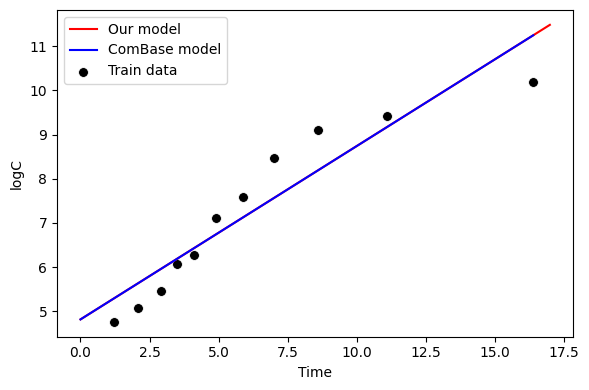

Text(0.5, 1.0, 'Linear model')

In [8]:
model = ClassicalModel()
model.fit(dummy_train['time'], dummy_train['logC'], model='linear')
print(f'{model.params=}')
t_model = np.linspace(0, 17, 20)
logC_model = model.predict(t_model)
fig, ax = plot_models({'time':t_model, 'logC':logC_model},
            dummy_val_linear,
            dummy_train)
ax.set_title('Linear model')

model2.params={'Initial Value': 4.499529078333809, 'Lag': 1.331097371518046, 'Maximum Rate': 1.5632372389335185, 'Final Value': 9.800124912213905}


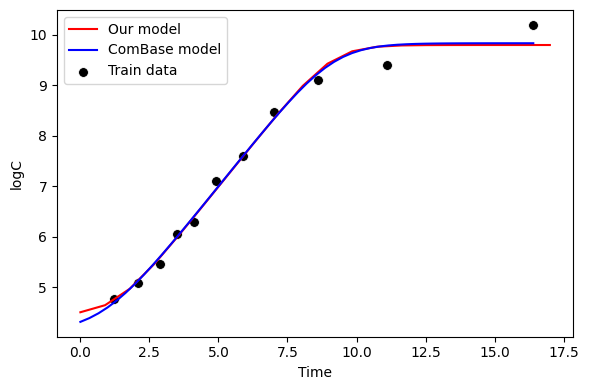

Text(0.5, 1.0, 'Baranyi and Roberts (1994) model')

In [11]:
model2 = ClassicalModel()
model2.fit(dummy_train['time'], dummy_train['logC'], model='baranyi')
print(f'{model2.params=}')
t_model = np.linspace(0, 17, 20)
logC_model = model2.predict(t_model)
fig, ax = plot_models({'time':t_model, 'logC':logC_model},
            dummy_val_baranyi,
            dummy_train)
ax.set_title('Baranyi and Roberts (1994) model')